In [1]:
from modules.utils import filter_df
from modules.viz import ConfigLookup, devplot
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
path = Path('./output/2025-11-20_16h02m24s_set_classif/')
dev = pd.read_csv(path/'dev.csv')
summary = pd.read_csv(path/'summary.csv')

figs = devplot(
    dev=dev,
    summary=summary,
    configs=['embed_dim128_depth2'],
    metrics='loss',
    figsize=(12,7),
)

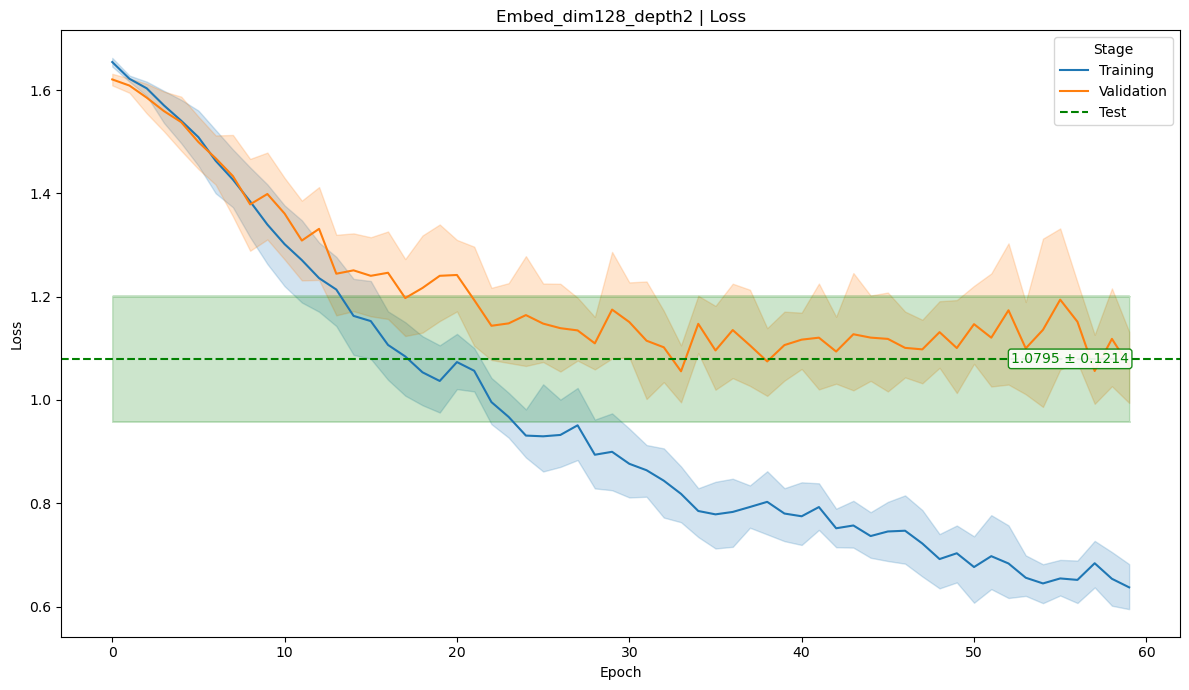

In [7]:
figs['embed_dim128_depth2']['loss']

---

In [8]:
path = Path('./output/2025-11-23_15h46m50s_classif_grid_1t_175configs')

conf_lookup = ConfigLookup(
    path=path,
    keys=['embed_dim','hidden_dims','lr'],
)

confs = conf_lookup.data
confs

,embed_dim,hidden_dims,lr,config
0,128,0,0.10000,embeddim128_hiddendims0_lr1e-1
1,128,0,0.01000,embeddim128_hiddendims0_lr1e-2
2,128,0,0.00100,embeddim128_hiddendims0_lr1e-3
3,128,0,0.00010,embeddim128_hiddendims0_lr1e-4
4,128,0,0.00001,embeddim128_hiddendims0_lr1e-5
...,...,...,...,...
170,64,6,0.10000,embeddim64_hiddendims6_lr1e-1
171,64,6,0.01000,embeddim64_hiddendims6_lr1e-2
172,64,6,0.00100,embeddim64_hiddendims6_lr1e-3
173,64,6,0.00010,embeddim64_hiddendims6_lr1e-4


---

In [50]:
# define path
path = Path('./output/2025-11-23_15h46m50s_classif_grid_1t_175configs')

# get confs
confs = ConfigLookup(path=path, keys=['embed_dim','hidden_dims','lr'],).data

# read
dev = pd.read_csv(path/'dev.csv')
test = pd.read_csv(path/'test.csv')
summary = pd.read_csv(path/'summary.csv')

# merge with confs
dev = pd.merge(confs,dev,on='config')
test = pd.merge(confs,test,on='config')
summary = pd.merge(confs,summary,on='config')

<Axes: xlabel='embed_dim', ylabel='value'>

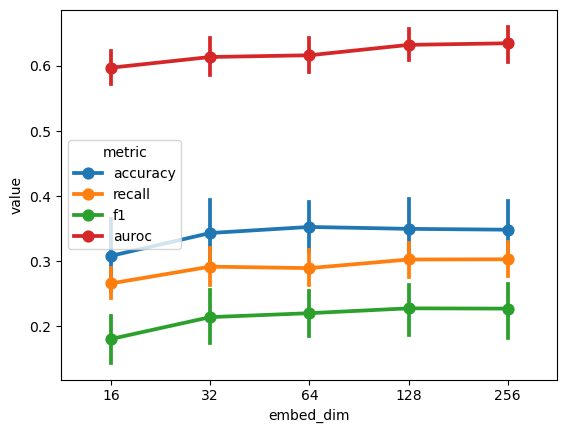

In [89]:
filt = filter_df(test, {'metric':['accuracy','precicion','recall','f1','auroc']})
sns.pointplot(filt, x='embed_dim', y='value', hue='metric')

<Axes: xlabel='hidden_dims', ylabel='value'>

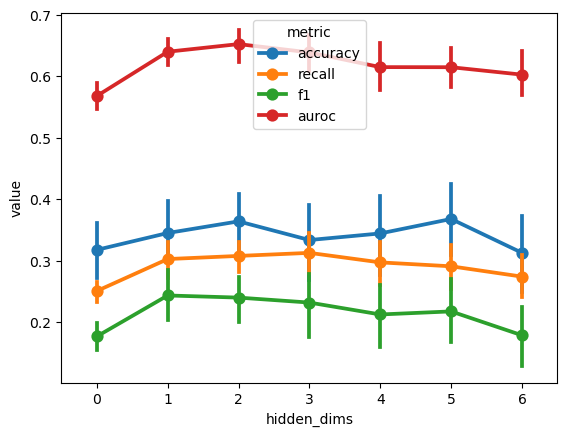

In [91]:
filt = filter_df(test, {'metric':['accuracy','precicion','recall','f1','auroc']})
sns.pointplot(filt, x='hidden_dims', y='value', hue='metric')

<Axes: xlabel='lr', ylabel='value'>

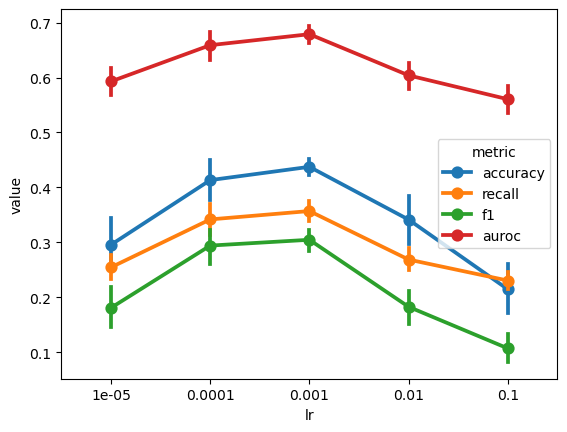

In [93]:
filt = filter_df(test, {'metric':['accuracy','precicion','recall','f1','auroc']})
sns.pointplot(filt, x='lr', y='value', hue='metric')

<Axes: xlabel='hidden_dims', ylabel='value'>

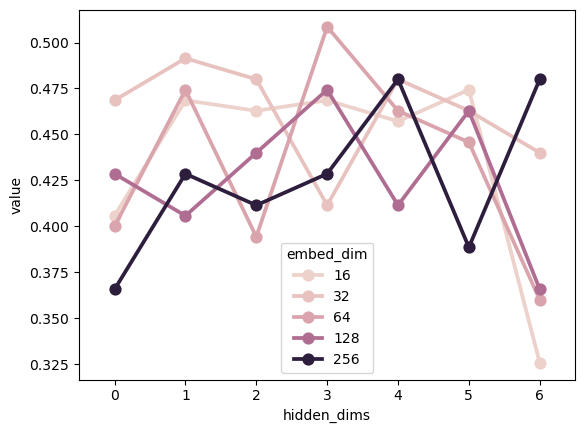

In [71]:
filt = filter_df(test, {'metric':'accuracy', 'lr':0.001})
sns.pointplot(filt, x='hidden_dims', y='value', hue='embed_dim')

<Axes: xlabel='embed_dim', ylabel='hidden_dims'>

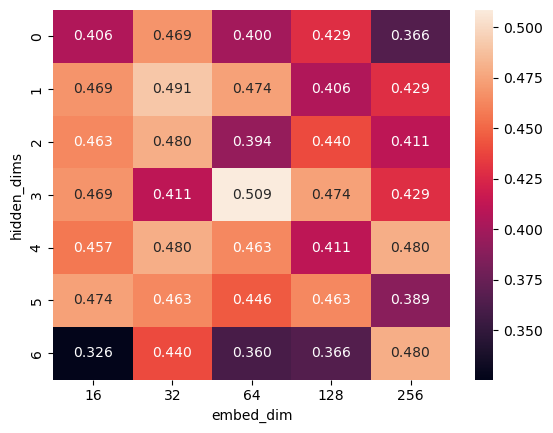

In [77]:
pivot = filt.pivot(
    columns='embed_dim',
    index='hidden_dims',
    values='value'
)

sns.heatmap(pivot, annot=True, fmt='.3f')

<Axes: xlabel='lr', ylabel='mean'>

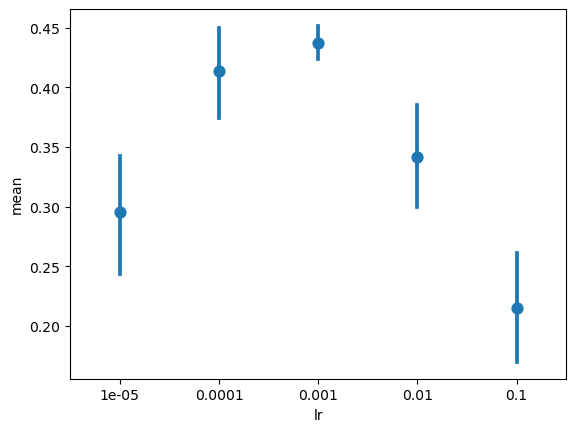

In [23]:
sns.pointplot(summary[summary['metric']=='accuracy'], x='lr', y='mean', linestyle='none')

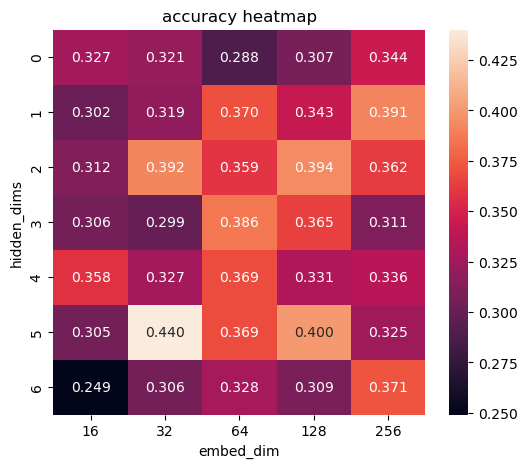

In [35]:
def plot1(df, metric:str='accuracy'):
    dfm = df[df["metric"] == metric]

    pivot = dfm.pivot_table(
        index="hidden_dims",
        columns="embed_dim",
        values="mean",
        aggfunc="mean"
    )

    plt.figure(figsize=(6,5))
    sns.heatmap(pivot, annot=True, fmt=".3f")
    plt.title(f"{metric} heatmap")
    plt.show()

plot1(summary, 'accuracy')

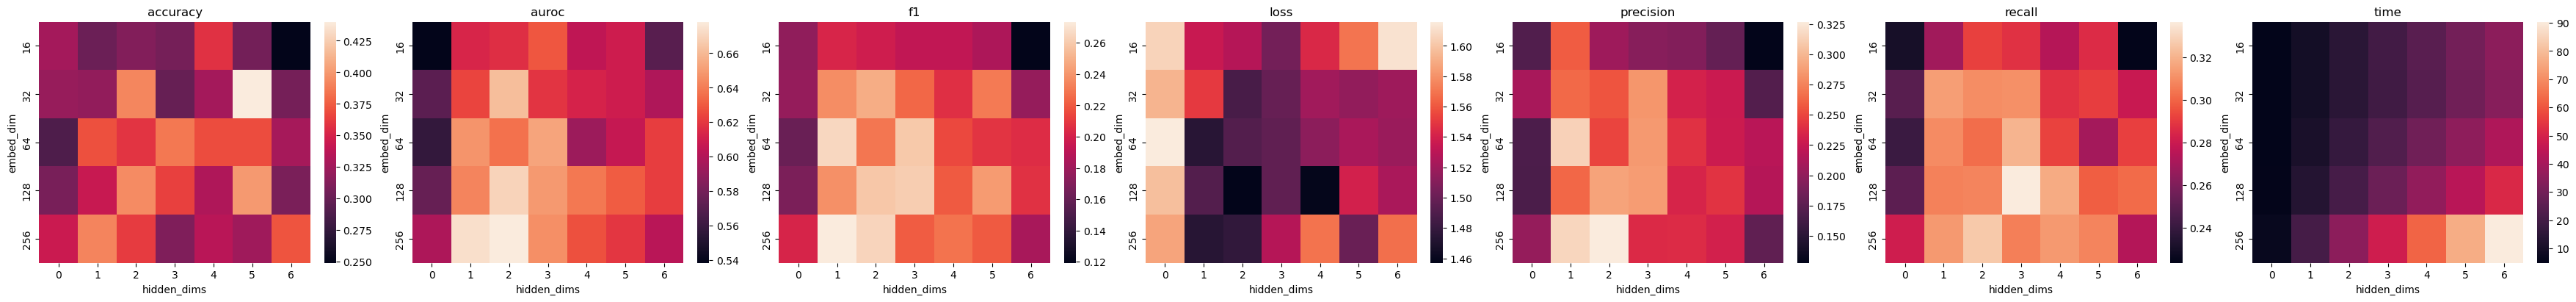

In [36]:
def plot2(df):
    metrics = df["metric"].unique()

    n = len(metrics)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4), constrained_layout=True)

    for ax, metric in zip(axes, metrics):
        dfm = df[df["metric"] == metric]
        pivot = dfm.pivot_table(
            index="embed_dim",
            columns="hidden_dims",
            values="mean"
        )
        sns.heatmap(pivot, annot=False, ax=ax)
        ax.set_title(metric)

    plt.show()

plot2(summary)

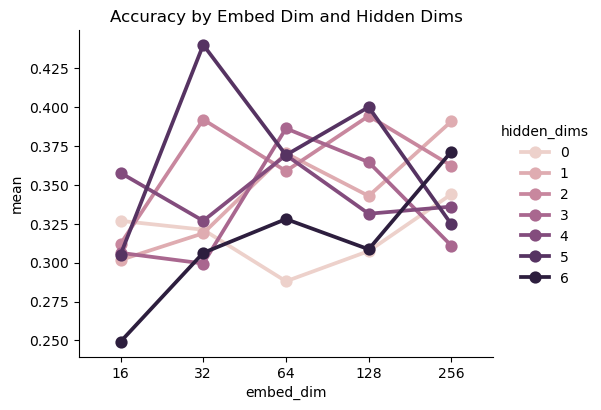

In [40]:
def plot3(df):
    sns.catplot(
        data=df[df["metric"]=="accuracy"],
        x="embed_dim",
        y="mean",
        hue="hidden_dims",
        kind="point",
        height=4,
        aspect=1.3,
        errorbar=None,
    )
    plt.title("Accuracy by Embed Dim and Hidden Dims")
    plt.show()

plot3(summary)

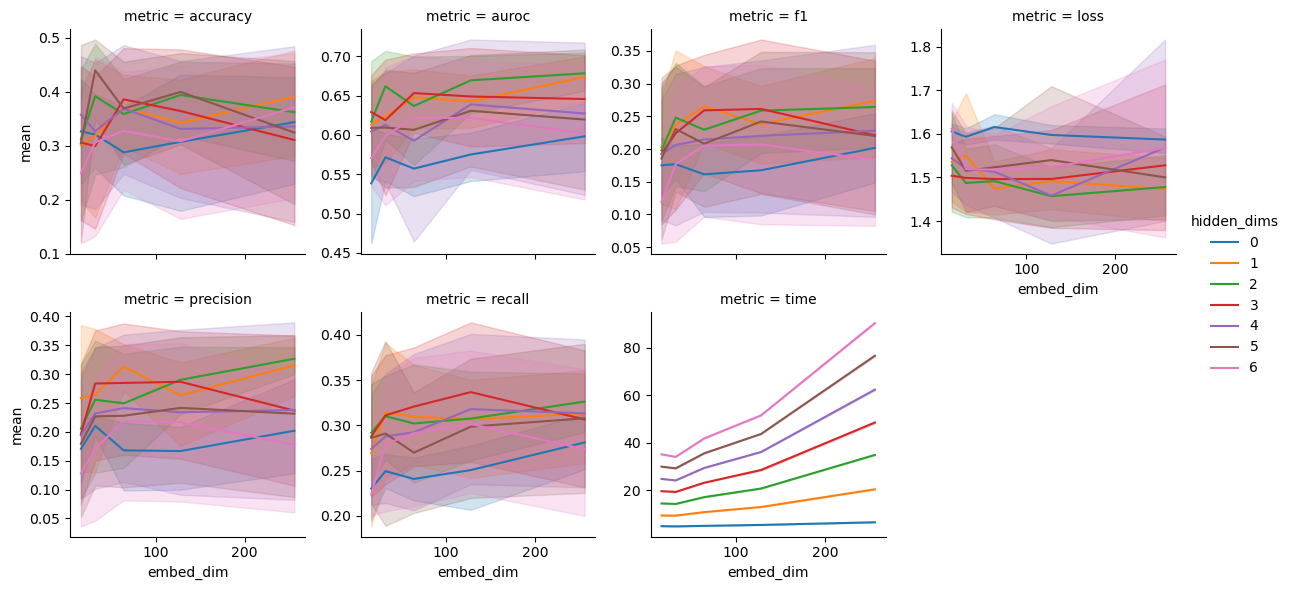

In [41]:
def plot4(df):
    g = sns.FacetGrid(
        df, 
        col="metric", 
        hue="hidden_dims", 
        sharey=False,
        col_wrap=4
    )
    g.map(sns.lineplot, "embed_dim", "mean")
    g.add_legend()
    plt.show()

plot4(summary)


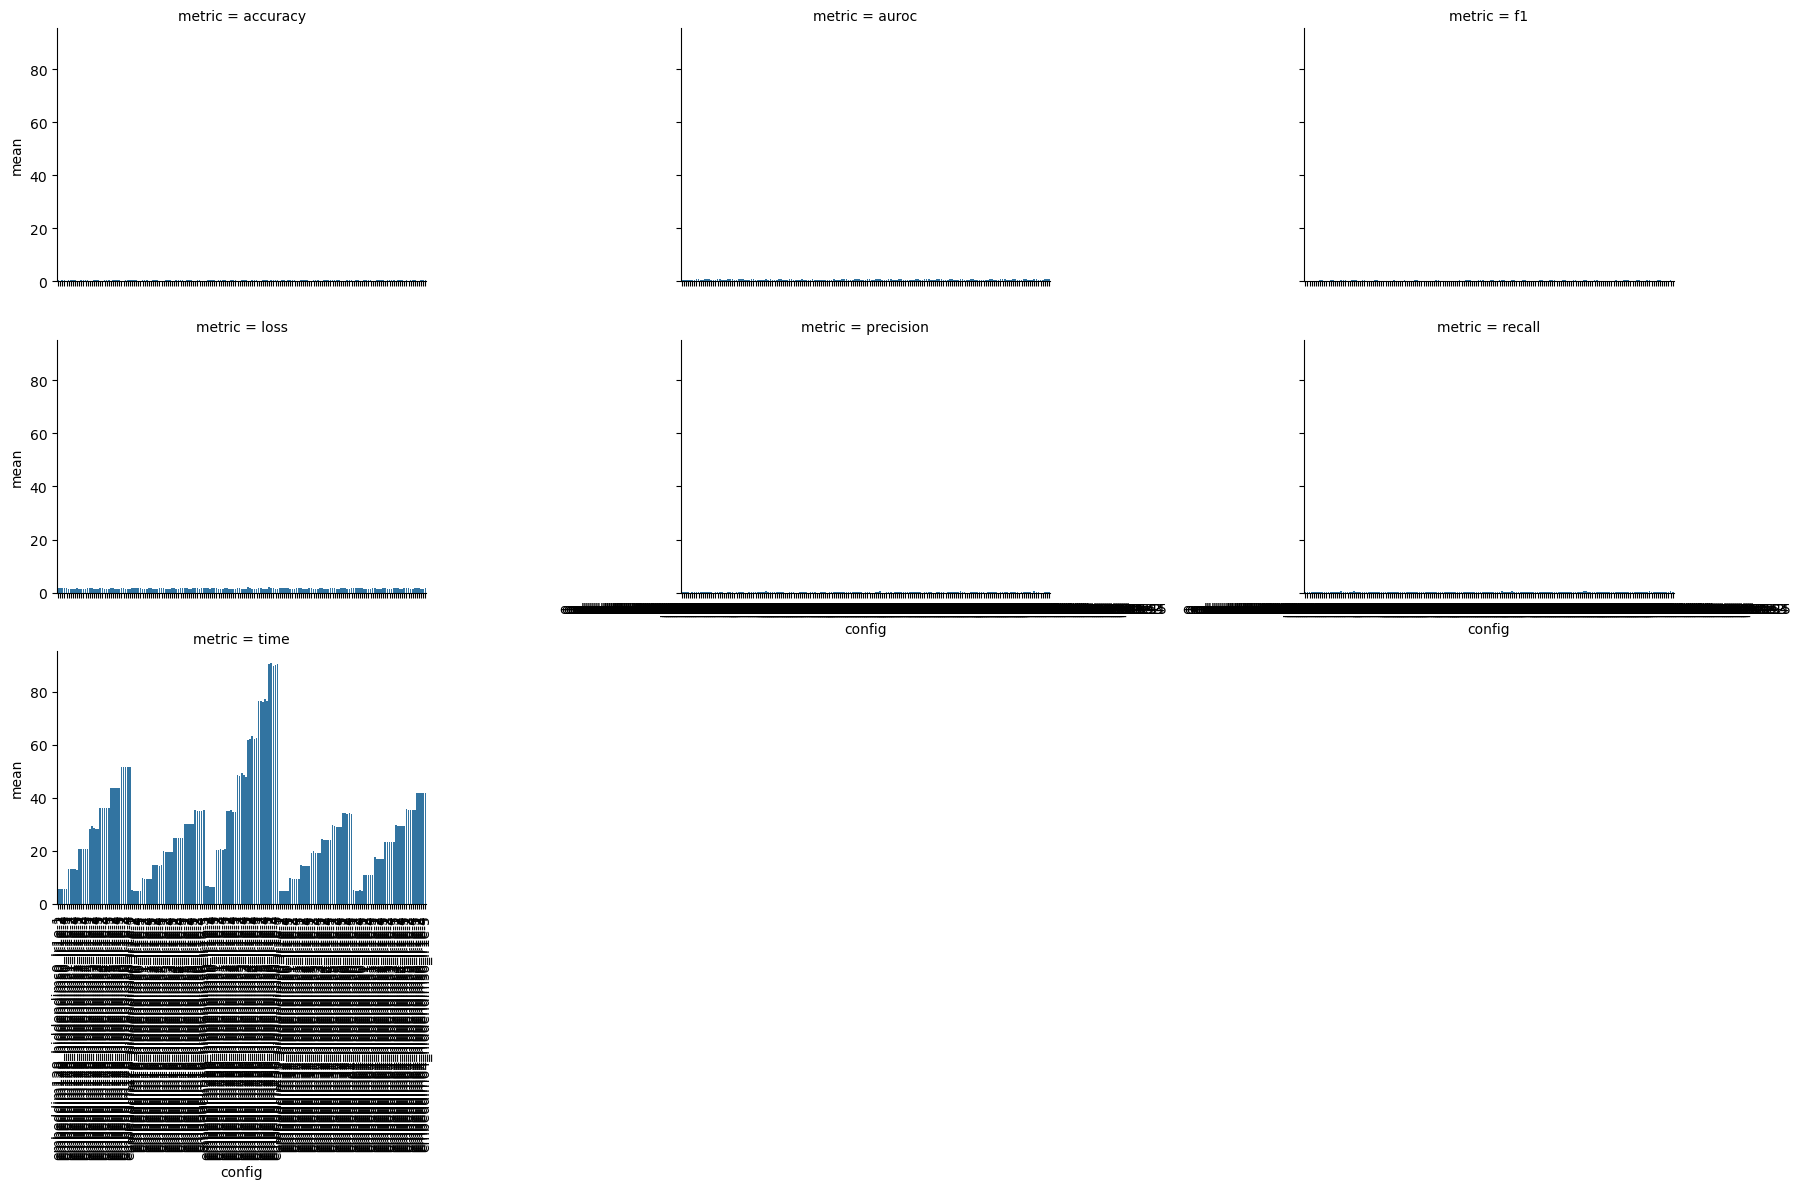

In [42]:
def plot5(df):
    sns.catplot(
        data=df,
        x="config",
        y="mean",
        col="metric",
        kind="bar",
        col_wrap=3,
        height=4,
        aspect=1.5
    )
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

plot5(summary)
